# 19. MERT 표현으로 12종 생성기 분류

이미 추출한 MERT layer별 표현에 LR을 학습한다. 전체 FAKE 집합과 18B의 엄격한 균형 집합에서 각각 Validation으로 layer를 고르고 Test의 곡 단위 결과를 비교한다.

## 1. 라이브러리 / 경로 / 입력 QC

In [1]:
from pathlib import Path
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

SEGMENT_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"

MERT_EMBED_PATH = PROJECT_ROOT / "data/processed/mert/mert95m_v2_layers_float16.npy"

MERT_DONE_PATH = PROJECT_ROOT / "data/processed/mert/mert95m_v2_done.npy"

STRICT_TRACKS_PATH = (
    PROJECT_ROOT
    / "results/generator_attribution/balanced_controlled/strict_selected_tracks.csv"
)

HANDCRAFTED_FULL_METRICS = (
    PROJECT_ROOT
    / "results/generator_attribution/handcrafted/generator_attribution_metrics.csv"
)

HANDCRAFTED_STRICT_METRICS = (
    PROJECT_ROOT
    / "results/generator_attribution/balanced_controlled/strict_balanced_metrics.csv"
)

RESULT_DIR = PROJECT_ROOT / "results/generator_attribution/mert"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/generator_attribution"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

for p in [
    SEGMENT_PATH,
    MERT_EMBED_PATH,
    MERT_DONE_PATH,
    STRICT_TRACKS_PATH,
]:
    print(p.name, "->", p.exists())
    if not p.exists():
        raise FileNotFoundError(p)

segments = pd.read_csv(SEGMENT_PATH).reset_index(drop=True)
# 배열 캐시를 읽어 저장된 특징과 ID의 순서를 확인한다.
mert_cache = np.load(MERT_EMBED_PATH, mmap_mode="r")
done = np.load(MERT_DONE_PATH)
strict_selected_tracks = pd.read_csv(STRICT_TRACKS_PATH)

print("\nSegments   :", len(segments))
print("MERT cache :", mert_cache.shape)
print("Done       :", int(done.sum()), "/", len(done))
print("Strict tracks:", len(strict_selected_tracks))

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(segments) == 10077
assert mert_cache.shape == (10077, 13, 768)
assert bool(done.all())
assert len(strict_selected_tracks) == 1428

print("Input QC PASS: True")

segment_manifest_10s.csv -> True
mert95m_v2_layers_float16.npy -> True
mert95m_v2_done.npy -> True
strict_selected_tracks.csv -> True

Segments   : 10077
MERT cache : (10077, 13, 768)
Done       : 10077 / 10077
Strict tracks: 1428
Input QC PASS: True


## 2. FAKE subset / generator / leakage QC

In [2]:
segments["cache_index"] = np.arange(len(segments))

fake = segments[segments["label"] == "FAKE"].copy()

generator_order = sorted(fake["generator"].dropna().unique().tolist())

encoder = LabelEncoder()
# 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
encoder.fit(generator_order)

print("FAKE segments:", len(fake))
print("Generators:", len(generator_order))
print(generator_order)

groups = {
    s: set(fake.loc[fake["split"] == s, "original_audio"])
    for s in ["train", "val", "test"]
}

print("Train∩Val :", len(groups["train"] & groups["val"]))
print("Train∩Test:", len(groups["train"] & groups["test"]))
print("Val∩Test  :", len(groups["val"] & groups["test"]))

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(fake) == 9189
assert len(generator_order) == 12
assert len(groups["train"] & groups["test"]) == 0

print("MERT Generator Split QC PASS: True")

FAKE segments: 9189
Generators: 12
['acestep', 'audioldm', 'brev', 'diffrhythm', 'elevenlabs', 'mubert', 'musicgen', 'producer', 'songgen', 'stableaudio', 'suno', 'udio']
Train∩Val : 0
Train∩Test: 0
Val∩Test  : 0
MERT Generator Split QC PASS: True


## 3. 평가 / Track aggregation 함수

In [3]:
# 평가 / Track aggregation 함수
def top_k_accuracy(y_true, score_matrix, k=3):
    topk = np.argsort(score_matrix, axis=1)[:, -k:]
    return float(np.mean([int(y) in row for y, row in zip(y_true, topk)]))


def macro_ovr_auc(y_true, score_matrix, n_classes):
    aucs = []

    for cls in range(n_classes):
        y_bin = (np.asarray(y_true) == cls).astype(int)

        if y_bin.min() == y_bin.max():
            continue

        aucs.append(
            roc_auc_score(
                y_bin,
                score_matrix[:, cls],
            )
        )

    return float(np.mean(aucs))


def evaluate_multiclass(y_true, score_matrix, n_classes):
    pred = np.argmax(score_matrix, axis=1)

    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "macro_f1": float(
            f1_score(
                y_true,
                pred,
                average="macro",
                zero_division=0,
            )
        ),
        "top3_accuracy": float(
            top_k_accuracy(
                y_true,
                score_matrix,
                3,
            )
        ),
        "macro_ovr_auc": float(
            macro_ovr_auc(
                y_true,
                score_matrix,
                n_classes,
            )
        ),
    }


def aggregate_track_probs(meta_df, probs, class_names):
    temp = (
        meta_df[
            [
                "track_sample_id",
                "original_audio",
                "generator",
                "genre",
                "split",
            ]
        ]
        .reset_index(drop=True)
        .copy()
    )

    prob_cols = []

    for j, cls in enumerate(class_names):
        col = f"prob__{cls}"
        prob_cols.append(col)
        temp[col] = probs[:, j]

    agg = {
        "original_audio": "first",
        "generator": "first",
        "genre": "first",
        "split": "first",
    }
    agg.update({c: "mean" for c in prob_cols})

    track = temp.groupby(
        "track_sample_id",
        as_index=False,
    ).agg(agg)

    return track, prob_cols

## 4. Experiment A — Full FAKE: 13개 MERT layer 탐색

각 layer마다:
- Train-only StandardScaler
- balanced Logistic Regression
- Validation segment / track 평가
- **Validation Track Macro-F1 최고 layer 선택**

Test는 layer 선택에 사용하지 않는다.

In [4]:
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
full_train = fake[fake["split"] == "train"].reset_index(drop=True)

full_val = fake[fake["split"] == "val"].reset_index(drop=True)

full_test = fake[fake["split"] == "test"].reset_index(drop=True)

train_idx = full_train["cache_index"].to_numpy()
val_idx = full_val["cache_index"].to_numpy()
test_idx = full_test["cache_index"].to_numpy()

# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
y_train = encoder.transform(full_train["generator"])
y_val = encoder.transform(full_val["generator"])
# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
y_test = encoder.transform(full_test["generator"])

layer_rows = []
full_artifacts = {}

for layer in range(13):
    X_train = np.asarray(
        mert_cache[train_idx, layer, :],
        dtype=np.float32,
    )
    X_val = np.asarray(
        mert_cache[val_idx, layer, :],
        dtype=np.float32,
    )

    # 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
    scaler = StandardScaler()
    # Train의 평균·표준편차를 구하고 같은 Train 행을 변환한다.
    X_train_z = scaler.fit_transform(X_train)
    X_val_z = scaler.transform(X_val)

    clf = LogisticRegression(
        # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
        class_weight="balanced",
        max_iter=3000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )

    # 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
    clf.fit(
        X_train_z,
        y_train,
    )

    # 확률 출력에서 모델이 예측한 클래스 순서에 맞는 점수 열을 사용한다.
    val_probs = clf.predict_proba(X_val_z)

    seg_metrics = evaluate_multiclass(
        y_val,
        val_probs,
        12,
    )

    val_track, prob_cols = aggregate_track_probs(
        full_val,
        val_probs,
        encoder.classes_,
    )

    y_val_track = encoder.transform(val_track["generator"])

    track_metrics = evaluate_multiclass(
        y_val_track,
        val_track[prob_cols].to_numpy(),
        12,
    )

    row = {
        "layer": layer,
        "val_segment_accuracy": seg_metrics["accuracy"],
        "val_segment_macro_f1": seg_metrics["macro_f1"],
        "val_track_accuracy": track_metrics["accuracy"],
        "val_track_balanced_accuracy": track_metrics["balanced_accuracy"],
        "val_track_macro_f1": track_metrics["macro_f1"],
        "val_track_top3": track_metrics["top3_accuracy"],
        "val_track_macro_ovr_auc": track_metrics["macro_ovr_auc"],
    }

    layer_rows.append(row)
    full_artifacts[layer] = {
        "scaler": scaler,
        "clf": clf,
    }

    print(
        f"layer {layer:02d} | "
        f"Val Track Macro-F1="
        f"{row['val_track_macro_f1']:.4f} | "
        f"Acc="
        f"{row['val_track_accuracy']:.4f}"
    )

full_layer_search = pd.DataFrame(layer_rows)

full_ranked = full_layer_search.sort_values(
    [
        "val_track_macro_f1",
        "val_track_balanced_accuracy",
        "val_track_macro_ovr_auc",
    ],
    ascending=[
        False,
        False,
        False,
    ],
).reset_index(drop=True)

display(full_ranked.round(4))

BEST_FULL_LAYER = int(full_ranked.iloc[0]["layer"])

print(
    "Best Full MERT layer:",
    BEST_FULL_LAYER,
)

layer 00 | Val Track Macro-F1=0.8469 | Acc=0.8592
layer 01 | Val Track Macro-F1=0.9078 | Acc=0.9130
layer 02 | Val Track Macro-F1=0.9016 | Acc=0.9110
layer 03 | Val Track Macro-F1=0.9094 | Acc=0.9130
layer 04 | Val Track Macro-F1=0.9073 | Acc=0.9172
layer 05 | Val Track Macro-F1=0.9141 | Acc=0.9151
layer 06 | Val Track Macro-F1=0.9055 | Acc=0.9110
layer 07 | Val Track Macro-F1=0.9190 | Acc=0.9193
layer 08 | Val Track Macro-F1=0.9036 | Acc=0.9048
layer 09 | Val Track Macro-F1=0.9251 | Acc=0.9296
layer 10 | Val Track Macro-F1=0.9396 | Acc=0.9379
layer 11 | Val Track Macro-F1=0.9071 | Acc=0.9172
layer 12 | Val Track Macro-F1=0.8862 | Acc=0.8944


,layer,val_segment_accuracy,val_segment_macro_f1,val_track_accuracy,val_track_balanced_accuracy,val_track_macro_f1,val_track_top3,val_track_macro_ovr_auc
0,10,0.8506,0.8492,0.9379,0.9371,0.9396,1.0000,0.9960
1,9,0.8485,0.8447,0.9296,0.9254,0.9251,0.9979,0.9956
2,7,0.8471,0.8463,0.9193,0.9161,0.9190,0.9896,0.9933
3,5,0.8414,0.8418,0.9151,0.9114,0.9141,0.9896,0.9927
4,3,0.8428,0.8378,0.9130,0.9068,0.9094,0.9834,0.9917
5,1,0.8428,0.8410,0.9130,0.9085,0.9078,0.9855,0.9924
6,4,0.8499,0.8466,0.9172,0.9058,0.9073,0.9959,0.9937
7,11,0.8186,0.8154,0.9172,0.9028,0.9071,0.9938,0.9946
8,6,0.8485,0.8464,0.9110,0.9030,0.9055,0.9896,0.9936
9,8,0.8428,0.8444,0.9048,0.9039,0.9036,0.9959,0.9947


Best Full MERT layer: 10


## 5. Full FAKE — Best layer Test 평가

In [5]:
full_scaler = full_artifacts[BEST_FULL_LAYER]["scaler"]

full_clf = full_artifacts[BEST_FULL_LAYER]["clf"]

X_val = np.asarray(
    mert_cache[val_idx, BEST_FULL_LAYER, :],
    dtype=np.float32,
)

X_test = np.asarray(
    mert_cache[test_idx, BEST_FULL_LAYER, :],
    dtype=np.float32,
)

# Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
val_probs = full_clf.predict_proba(full_scaler.transform(X_val))

# `predict_proba`로 각 클래스의 예측 확률을 얻는다.
# Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
test_probs = full_clf.predict_proba(full_scaler.transform(X_test))

segment_val_metrics = evaluate_multiclass(
    y_val,
    val_probs,
    12,
)

segment_test_metrics = evaluate_multiclass(
    y_test,
    test_probs,
    12,
)

val_track, prob_cols = aggregate_track_probs(
    full_val,
    val_probs,
    encoder.classes_,
)

test_track, _ = aggregate_track_probs(
    full_test,
    test_probs,
    encoder.classes_,
)

y_val_track = encoder.transform(val_track["generator"])

y_test_track = encoder.transform(test_track["generator"])

track_val_metrics = evaluate_multiclass(
    y_val_track,
    val_track[prob_cols].to_numpy(),
    12,
)

track_test_metrics = evaluate_multiclass(
    y_test_track,
    test_track[prob_cols].to_numpy(),
    12,
)

full_metrics = pd.DataFrame(
    [
        {
            "representation": "MERT95M",
            "experiment": "full",
            "level": "segment",
            "split": "val",
            "best_layer": BEST_FULL_LAYER,
            **segment_val_metrics,
        },
        {
            "representation": "MERT95M",
            "experiment": "full",
            "level": "segment",
            "split": "test",
            "best_layer": BEST_FULL_LAYER,
            **segment_test_metrics,
        },
        {
            "representation": "MERT95M",
            "experiment": "full",
            "level": "track",
            "split": "val",
            "best_layer": BEST_FULL_LAYER,
            **track_val_metrics,
        },
        {
            "representation": "MERT95M",
            "experiment": "full",
            "level": "track",
            "split": "test",
            "best_layer": BEST_FULL_LAYER,
            **track_test_metrics,
        },
    ]
)

display(full_metrics.round(4))

,representation,experiment,level,split,best_layer,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
0,MERT95M,full,segment,val,10,0.8506,0.8506,0.8492,0.9765,0.9860
1,MERT95M,full,segment,test,10,0.8441,0.8392,0.8416,0.9777,0.9873
2,MERT95M,full,track,val,10,0.9379,0.9371,0.9396,1.0000,0.9960
3,MERT95M,full,track,test,10,0.9393,0.9379,0.9384,0.9879,0.9959


## 6. Full Test — generator별 MERT 성능 / confusion matrix

,generator,precision,recall,f1-score,support
0,acestep,1.0000,1.0000,1.0000,45.0
6,musicgen,1.0000,1.0000,1.0000,45.0
8,songgen,1.0000,1.0000,1.0000,45.0
3,diffrhythm,0.9592,1.0000,0.9792,47.0
4,elevenlabs,0.9792,0.9792,0.9792,48.0
11,udio,0.9792,0.9792,0.9792,48.0
1,audioldm,0.9778,0.9778,0.9778,45.0
5,mubert,1.0000,0.8750,0.9333,24.0
9,stableaudio,0.8929,0.9615,0.9259,26.0
7,producer,0.9200,0.9200,0.9200,25.0


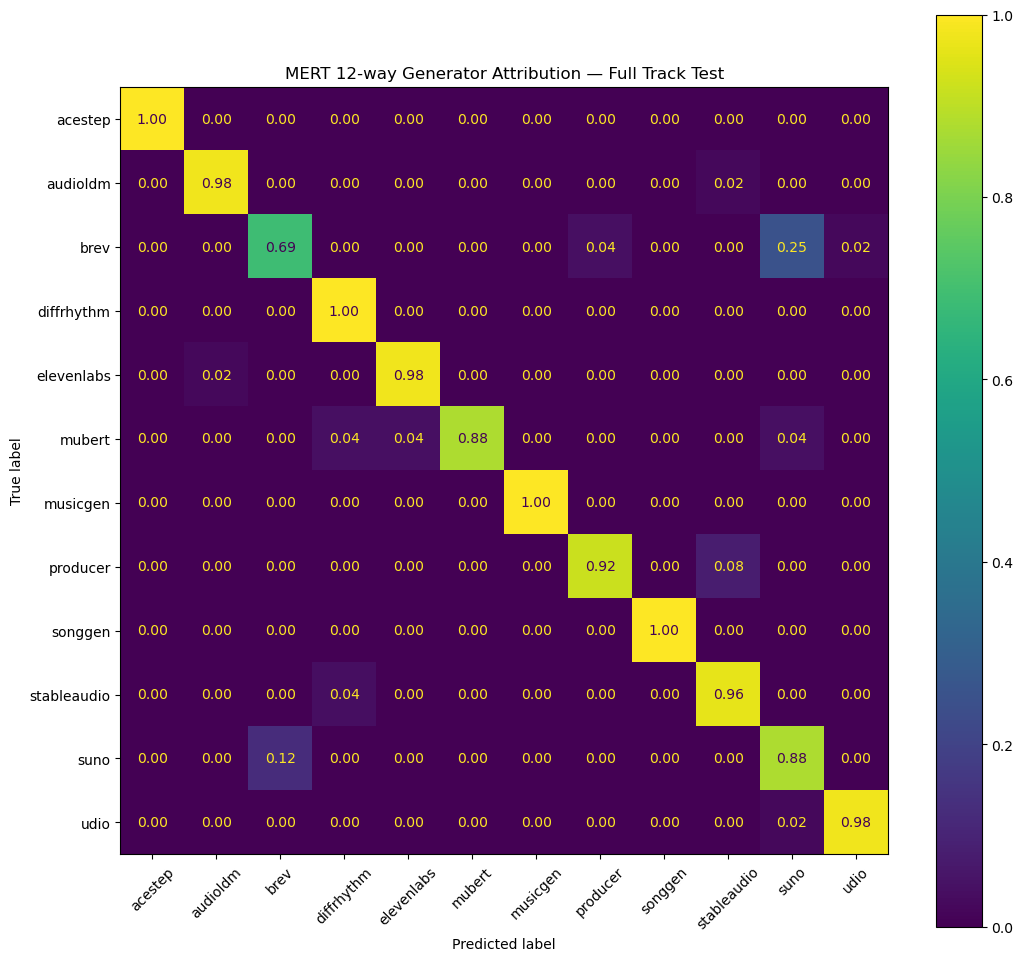

In [6]:
full_test_scores = test_track[prob_cols].to_numpy()

full_pred_int = np.argmax(
    full_test_scores,
    axis=1,
)

full_pred = encoder.inverse_transform(full_pred_int)

full_report = classification_report(
    test_track["generator"],
    full_pred,
    labels=encoder.classes_,
    output_dict=True,
    zero_division=0,
)

full_per_generator = (
    pd.DataFrame(full_report)
    .T.loc[
        encoder.classes_,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
    .reset_index()
    .rename(columns={"index": "generator"})
)

display(
    full_per_generator.sort_values(
        "f1-score",
        ascending=False,
    ).round(4)
)

full_cm = confusion_matrix(
    test_track["generator"],
    full_pred,
    labels=encoder.classes_,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(11, 10))

ConfusionMatrixDisplay(
    full_cm,
    display_labels=encoder.classes_,
).plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
)

ax.set_title("MERT 12-way Generator Attribution — Full Track Test")

fig.tight_layout()

fig.savefig(
    RESULT_DIR / "mert_full_track_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 7. Experiment B — Strict Balanced Track MERT dataset 생성

18-B에서 선택한 정확히 1개의 `original_audio × generator` track만 사용한다.

각 track에 속한 segment의 MERT embedding을 평균해:
- track당 1개 vector
- layer당 768-D
로 만든다.

In [7]:
strict_ids = set(strict_selected_tracks["track_sample_id"])

strict_segments = fake[fake["track_sample_id"].isin(strict_ids)].copy()

strict_track_rows = []

# 같은 곡의 10초 구간을 묶어 곡 단위 결과를 만든다.
for track_id, group in strict_segments.groupby("track_sample_id"):
    cache_indices = group["cache_index"].to_numpy().astype(int)

    # [segments, 13, 768] -> [13, 768]
    track_emb = np.asarray(
        mert_cache[cache_indices, :, :],
        dtype=np.float32,
    ).mean(axis=0)

    first = group.iloc[0]

    strict_track_rows.append(
        {
            "track_sample_id": track_id,
            "original_audio": first["original_audio"],
            "generator": first["generator"],
            "genre": first["genre"],
            "split": first["split"],
            "embedding": track_emb,
        }
    )

strict_track_df = pd.DataFrame(strict_track_rows)

print("Strict MERT track rows:", len(strict_track_df))

print("\nDistribution")
display(
    pd.crosstab(
        strict_track_df["generator"],
        strict_track_df["split"],
    )
)

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(strict_track_df) == 1428

dist = pd.crosstab(
    strict_track_df["generator"],
    strict_track_df["split"],
)

assert dist["train"].nunique() == 1
assert dist["val"].nunique() == 1
assert dist["test"].nunique() == 1
assert int(dist["train"].iloc[0]) == 83
assert int(dist["val"].iloc[0]) == 17
assert int(dist["test"].iloc[0]) == 19

print("Strict MERT Track Dataset QC PASS: True")

Strict MERT track rows: 1428

Distribution


split,test,train,val
generator,,,
acestep,19,83,17
audioldm,19,83,17
brev,19,83,17
diffrhythm,19,83,17
elevenlabs,19,83,17
mubert,19,83,17
musicgen,19,83,17
producer,19,83,17
songgen,19,83,17


Strict MERT Track Dataset QC PASS: True


## 8. Strict Balanced — 13개 MERT layer 탐색

In [8]:
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
strict_train = strict_track_df[strict_track_df["split"] == "train"].reset_index(
    drop=True
)

strict_val = strict_track_df[strict_track_df["split"] == "val"].reset_index(drop=True)

strict_test = strict_track_df[strict_track_df["split"] == "test"].reset_index(drop=True)

# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
sy_train = encoder.transform(strict_train["generator"])

# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
sy_val = encoder.transform(strict_val["generator"])

sy_test = encoder.transform(strict_test["generator"])

strict_layer_rows = []
strict_artifacts = {}

for layer in range(13):
    SX_train = np.stack([emb[layer] for emb in strict_train["embedding"]]).astype(
        np.float32
    )

    SX_val = np.stack([emb[layer] for emb in strict_val["embedding"]]).astype(
        np.float32
    )

    # 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
    scaler = StandardScaler()
    # Train의 평균·표준편차를 구하고 같은 Train 행을 변환한다.
    SX_train_z = scaler.fit_transform(SX_train)
    SX_val_z = scaler.transform(SX_val)

    clf = LogisticRegression(
        # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
        class_weight=None,
        max_iter=3000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )

    # 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
    clf.fit(
        SX_train_z,
        sy_train,
    )

    # 확률 출력에서 모델이 예측한 클래스 순서에 맞는 점수 열을 사용한다.
    val_probs = clf.predict_proba(SX_val_z)

    m = evaluate_multiclass(
        sy_val,
        val_probs,
        12,
    )

    row = {
        "layer": layer,
        "val_accuracy": m["accuracy"],
        "val_balanced_accuracy": m["balanced_accuracy"],
        "val_macro_f1": m["macro_f1"],
        "val_top3": m["top3_accuracy"],
        "val_macro_ovr_auc": m["macro_ovr_auc"],
    }

    strict_layer_rows.append(row)

    strict_artifacts[layer] = {
        "scaler": scaler,
        "clf": clf,
    }

    print(
        f"layer {layer:02d} | "
        f"Val Macro-F1="
        f"{row['val_macro_f1']:.4f} | "
        f"Acc="
        f"{row['val_accuracy']:.4f}"
    )

strict_layer_search = pd.DataFrame(strict_layer_rows)

strict_ranked = strict_layer_search.sort_values(
    [
        "val_macro_f1",
        "val_balanced_accuracy",
        "val_macro_ovr_auc",
    ],
    ascending=[
        False,
        False,
        False,
    ],
).reset_index(drop=True)

display(strict_ranked.round(4))

BEST_STRICT_LAYER = int(strict_ranked.iloc[0]["layer"])

print(
    "Best Strict MERT layer:",
    BEST_STRICT_LAYER,
)

layer 00 | Val Macro-F1=0.8088 | Acc=0.8088
layer 01 | Val Macro-F1=0.8480 | Acc=0.8480
layer 02 | Val Macro-F1=0.8670 | Acc=0.8676
layer 03 | Val Macro-F1=0.8707 | Acc=0.8725
layer 04 | Val Macro-F1=0.8567 | Acc=0.8578
layer 05 | Val Macro-F1=0.8695 | Acc=0.8725
layer 06 | Val Macro-F1=0.8456 | Acc=0.8480
layer 07 | Val Macro-F1=0.8513 | Acc=0.8578
layer 08 | Val Macro-F1=0.8473 | Acc=0.8529
layer 09 | Val Macro-F1=0.8720 | Acc=0.8725
layer 10 | Val Macro-F1=0.8820 | Acc=0.8824
layer 11 | Val Macro-F1=0.8575 | Acc=0.8529
layer 12 | Val Macro-F1=0.8370 | Acc=0.8382


,layer,val_accuracy,val_balanced_accuracy,val_macro_f1,val_top3,val_macro_ovr_auc
0,10,0.8824,0.8824,0.8820,0.9755,0.9886
1,9,0.8725,0.8725,0.8720,0.9853,0.9903
2,3,0.8725,0.8725,0.8707,0.9657,0.9888
3,5,0.8725,0.8725,0.8695,0.9706,0.9862
4,2,0.8676,0.8676,0.8670,0.9902,0.9882
5,11,0.8529,0.8529,0.8575,0.9755,0.9842
6,4,0.8578,0.8578,0.8567,0.9902,0.9903
7,7,0.8578,0.8578,0.8513,0.9853,0.9875
8,1,0.8480,0.8480,0.8480,0.9853,0.9854
9,8,0.8529,0.8529,0.8473,0.9853,0.9894


Best Strict MERT layer: 10


## 9. Strict Balanced — Best layer Test

In [9]:
strict_scaler = strict_artifacts[BEST_STRICT_LAYER]["scaler"]

strict_clf = strict_artifacts[BEST_STRICT_LAYER]["clf"]

SX_val = np.stack([emb[BEST_STRICT_LAYER] for emb in strict_val["embedding"]]).astype(
    np.float32
)

SX_test = np.stack([emb[BEST_STRICT_LAYER] for emb in strict_test["embedding"]]).astype(
    np.float32
)

# Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
strict_val_probs = strict_clf.predict_proba(strict_scaler.transform(SX_val))

# `predict_proba`로 각 클래스의 예측 확률을 얻는다.
# Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
strict_test_probs = strict_clf.predict_proba(strict_scaler.transform(SX_test))

strict_val_metrics = evaluate_multiclass(
    sy_val,
    strict_val_probs,
    12,
)

strict_test_metrics = evaluate_multiclass(
    sy_test,
    strict_test_probs,
    12,
)

strict_metrics = pd.DataFrame(
    [
        {
            "representation": "MERT95M",
            "experiment": "strict_balanced_controlled",
            "split": "val",
            "best_layer": BEST_STRICT_LAYER,
            **strict_val_metrics,
        },
        {
            "representation": "MERT95M",
            "experiment": "strict_balanced_controlled",
            "split": "test",
            "best_layer": BEST_STRICT_LAYER,
            **strict_test_metrics,
        },
    ]
)

display(strict_metrics.round(4))

print(
    "Chance Top-1:",
    round(1 / 12, 4),
)

,representation,experiment,split,best_layer,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
0,MERT95M,strict_balanced_controlled,val,10,0.8824,0.8824,0.882,0.9755,0.9886
1,MERT95M,strict_balanced_controlled,test,10,0.8991,0.8991,0.898,0.9912,0.9920


Chance Top-1: 0.0833


## 10. Handcrafted vs MERT — Full / Strict 비교

In [10]:
if not HANDCRAFTED_FULL_METRICS.exists():
    raise FileNotFoundError(HANDCRAFTED_FULL_METRICS)

if not HANDCRAFTED_STRICT_METRICS.exists():
    raise FileNotFoundError(HANDCRAFTED_STRICT_METRICS)

h_full = pd.read_csv(HANDCRAFTED_FULL_METRICS)

h_strict = pd.read_csv(HANDCRAFTED_STRICT_METRICS)

h_full_test = h_full[
    (h_full["experiment"] == "full")
    & (h_full["level"] == "track")
    # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
    & (h_full["split"] == "test")
].copy()

h_full_test["representation"] = "Handcrafted+RBF-SVM"

h_strict_test = h_strict[h_strict["split"] == "test"].copy()

h_strict_test["representation"] = "Handcrafted+RBF-SVM"

m_full_test = full_metrics[
    (full_metrics["level"] == "track") & (full_metrics["split"] == "test")
].copy()

m_full_test["representation"] = "MERT95M+LR"

m_strict_test = strict_metrics[strict_metrics["split"] == "test"].copy()

m_strict_test["representation"] = "MERT95M+LR"

compare_cols = [
    "representation",
    "experiment",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "top3_accuracy",
    "macro_ovr_auc",
]

comparison = pd.concat(
    [
        h_full_test[compare_cols],
        m_full_test[compare_cols],
        h_strict_test[compare_cols],
        m_strict_test[compare_cols],
    ],
    ignore_index=True,
)

display(comparison.round(4))

,representation,experiment,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
0,Handcrafted+RBF-SVM,full,0.8846,0.8812,0.8840,0.9798,0.9765
1,MERT95M+LR,full,0.9393,0.9379,0.9384,0.9879,0.9959
2,Handcrafted+RBF-SVM,strict_balanced_controlled,0.7544,0.7544,0.7447,0.9386,0.9534
3,MERT95M+LR,strict_balanced_controlled,0.8991,0.8991,0.8980,0.9912,0.9920


## 11. 저장 / 최종 QC

In [11]:
full_layer_search.to_csv(
    RESULT_DIR / "mert_full_layer_search.csv",
    index=False,
    encoding="utf-8-sig",
)

strict_layer_search.to_csv(
    RESULT_DIR / "mert_strict_layer_search.csv",
    index=False,
    encoding="utf-8-sig",
)

full_metrics.to_csv(
    RESULT_DIR / "mert_full_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

strict_metrics.to_csv(
    RESULT_DIR / "mert_strict_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

full_per_generator.to_csv(
    RESULT_DIR / "mert_full_per_generator_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

comparison.to_csv(
    RESULT_DIR / "handcrafted_vs_mert_generator_attribution.csv",
    index=False,
    encoding="utf-8-sig",
)

full_artifact = CHECKPOINT_DIR / "generator_attribution_mert_full_lr.joblib"

strict_artifact = CHECKPOINT_DIR / "generator_attribution_mert_strict_lr.joblib"

joblib.dump(
    {
        "classes": encoder.classes_.tolist(),
        "best_layer": BEST_FULL_LAYER,
        "scaler": full_scaler,
        "classifier": full_clf,
    },
    full_artifact,
)

joblib.dump(
    {
        "classes": encoder.classes_.tolist(),
        "best_layer": BEST_STRICT_LAYER,
        "scaler": strict_scaler,
        "classifier": strict_clf,
    },
    strict_artifact,
)

full_test_row = full_metrics[
    # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
    (full_metrics["level"] == "track") & (full_metrics["split"] == "test")
].iloc[0]

strict_test_row = strict_metrics[strict_metrics["split"] == "test"].iloc[0]

qc = pd.DataFrame(
    {
        "check": [
            "mert_cache_complete",
            "fake_segments",
            "generator_count",
            "full_best_layer_valid",
            "strict_track_rows",
            "strict_best_layer_valid",
            "finite_full_macro_f1",
            "finite_strict_macro_f1",
            "full_artifact_exists",
            "strict_artifact_exists",
        ],
        "value": [
            bool(done.all()),
            len(fake),
            len(generator_order),
            0 <= BEST_FULL_LAYER <= 12,
            len(strict_track_df),
            0 <= BEST_STRICT_LAYER <= 12,
            np.isfinite(full_test_row["macro_f1"]),
            np.isfinite(strict_test_row["macro_f1"]),
            full_artifact.exists(),
            strict_artifact.exists(),
        ],
    }
)

display(qc)

core_qc_pass = (
    bool(done.all())
    and len(fake) == 9189
    and len(generator_order) == 12
    and 0 <= BEST_FULL_LAYER <= 12
    and len(strict_track_df) == 1428
    and 0 <= BEST_STRICT_LAYER <= 12
    and np.isfinite(full_test_row["macro_f1"])
    and np.isfinite(strict_test_row["macro_f1"])
    and full_artifact.exists()
    and strict_artifact.exists()
)

print("===== FINAL RESULT =====")
print(
    "MERT Generator Attribution Core QC PASS:",
    core_qc_pass,
)

,check,value
0,mert_cache_complete,True
1,fake_segments,9189
2,generator_count,12
3,full_best_layer_valid,True
4,strict_track_rows,1428
5,strict_best_layer_valid,True
6,finite_full_macro_f1,True
7,finite_strict_macro_f1,True
8,full_artifact_exists,True
9,strict_artifact_exists,True


===== FINAL RESULT =====
MERT Generator Attribution Core QC PASS: True


## MERT 생성기 분류 결과

Full과 strict balanced 집합에서 MERT 층을 Validation으로 각각 선택한 뒤 Test를 평가했다. 곡 단위 성능은 [수작업 특징과 MERT 비교표](../results/generator_attribution/mert/handcrafted_vs_mert_generator_attribution.csv)에, 생성기별 오류는 [Full 혼동행렬](../results/generator_attribution/mert/mert_full_track_confusion_matrix.png)에 남아 있다. Strict balanced 결과는 원곡과 생성기별 곡 수를 맞춘 조건이므로 Full 수치와 표본 구성이 다르다.